<font size="+3"><strong>Predicting Price with Size, Location, and Neighborhood</strong></font>

In [1]:
from glob import glob

import pandas as pd
import seaborn as sns
from category_encoders import OneHotEncoder
from ipywidgets import Dropdown, FloatSlider, IntSlider, interact
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.utils.validation import check_is_fitted
from sklearn.model_selection import train_test_split

In the final lesson for this project, we're going to try to use all the features in our dataset to improve our model. This means that we'll have to do a more careful cleaning of the dataset and consider some of the finer points of linear models.

## Prepare Data

### Import

In [4]:
def wrangle(filepath):
    # Read CSV file
    df = pd.read_csv(filepath)

    # Subset data: Apartments in "Capital Federal", less than 400,000
    mask_ba = df["place_with_parent_names"].str.contains("Capital Federal")
    mask_apt = df["property_type"] == "apartment"
    mask_price = df["price_aprox_usd"] < 400_000
    df = df[mask_ba & mask_apt & mask_price]

    # Subset data: Remove outliers for "surface_covered_in_m2"
    low, high = df["surface_covered_in_m2"].quantile([0.1, 0.9])
    mask_area = df["surface_covered_in_m2"].between(low, high)
    df = df[mask_area]

    # Split "lat-lon" column
    df[["lat", "lon"]] = df["lat-lon"].str.split(",", expand=True).astype(float)
    df.drop(columns="lat-lon", inplace=True)

    # Get place name
    df["neighborhood"] = df["place_with_parent_names"].str.split("|", expand=True)[3]
    df.drop(columns="place_with_parent_names", inplace=True)

    # Drop features with high null counts
    df.drop(columns=["floor", "expenses"], inplace=True)

    #Drop low and high cardinality categorical variables
    df.drop(columns=["operation", "property_type", "currency", "properati_url"], 
           inplace = True)
    
    # Drop the leakage columns   (Leaky columns is associated with the target variable)
    df.drop(columns=['price', 'price_aprox_local_currency','price_per_m2',
            'price_usd_per_m2'], inplace=True)

    # Drop columns with multi co-linearity 
    df.drop(columns=["surface_total_in_m2", "rooms"], inplace = True)
    
    return df

**Task 1:** Use [`glob`](https://docs.python.org/3/library/glob.html#glob.glob) to create a list that contains the filenames for all the Buenos Aires real estate CSV files in the `data` directory. Assign this list to the variable name `files`.

In [5]:
files = glob("buenos-aires-real-estate-*.csv")
files

['buenos-aires-real-estate-1.csv',
 'buenos-aires-real-estate-2.csv',
 'buenos-aires-real-estate-3.csv',
 'buenos-aires-real-estate-4.csv',
 'buenos-aires-real-estate-5.csv']

We are going to import all the datasets with a compact coding technique known as **list comprehension**.

**Task 2:** Use your `wrangle` function in a list comprehension to create a list named `frames`. The list should contain the cleaned DataFrames for the filenames your collected in `files`.

In [6]:
frames = [wrangle(file) for file in files]
frames[0].head()

,price_aprox_usd,surface_covered_in_m2,lat,lon,neighborhood
4,129000.0,70.0,-34.584651,-58.454693,Chacarita
9,87000.0,42.0,-34.638979,-58.500115,Villa Luro
29,118000.0,54.0,-34.615847,-58.459957,Caballito
40,57000.0,42.0,-34.625222,-58.382382,Constitución
41,90000.0,50.0,-34.610610,-58.412511,Once


**Task 3:** Use [`pd.concat`](https://pandas.pydata.org/docs/reference/api/pandas.concat.html) to concatenate it items in `frames` into a single DataFrame `df`. Make sure you set the `ignore_index` argument to `True`.

In [7]:
df = pd.concat(frames, ignore_index=True)
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6582 entries, 0 to 6581
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   price_aprox_usd        6582 non-null   float64
 1   surface_covered_in_m2  6582 non-null   float64
 2   lat                    6316 non-null   float64
 3   lon                    6316 non-null   float64
 4   neighborhood           6582 non-null   object 
dtypes: float64(4), object(1)
memory usage: 257.2+ KB
None


,price_aprox_usd,surface_covered_in_m2,lat,lon,neighborhood
0,129000.0,70.0,-34.584651,-58.454693,Chacarita
1,87000.0,42.0,-34.638979,-58.500115,Villa Luro
2,118000.0,54.0,-34.615847,-58.459957,Caballito
3,57000.0,42.0,-34.625222,-58.382382,Constitución
4,90000.0,50.0,-34.610610,-58.412511,Once


### Explore

The first thing we need to consider when trying to use all the features `df` is **missing values**. While it's true you can impute missing values, there still needs to be enough data in a column to do a good imputation. A general rule is that, if more than half of the data in a column is missing, it's better to drop it then try imputing.

Take a look at the output from `df.info()` above. Are there columns where more than half of the values are `NaN`? If so, those columns need to go!

**Task 4:** Modify your `wrangle` function to drop any columns that are more than half `NaN` values. Be sure to rerun all the cells above before you continue.

The next thing we need to look out for are categorical columns with **low or high cardinality**. If there's only one category in a column, it won't provide any unique information to our model. At the other extreme, columns where nearly every row has its own category won't help our model in identifying useful trends in the data.

Let's take a look at the cardinality of our features.

**Task 5:** Calculate the number of unique values for each non-numeric feature in `df`.

In [10]:
# df.select_dtypes("object").head()
df.select_dtypes("object").nunique()

neighborhood    57
dtype: int64

Here, we can see that columns like `"operation"` have only one value in them, while every row in `"properati_url"` has a unique value. These are clear examples of high- and low-cardinality features that we shouldn't include in our model.

In [12]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6582 entries, 0 to 6581
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   price_aprox_usd        6582 non-null   float64
 1   surface_covered_in_m2  6582 non-null   float64
 2   lat                    6316 non-null   float64
 3   lon                    6316 non-null   float64
 4   neighborhood           6582 non-null   object 
dtypes: float64(4), object(1)
memory usage: 257.2+ KB


,price_aprox_usd,surface_covered_in_m2,lat,lon,neighborhood
0,129000.0,70.0,-34.584651,-58.454693,Chacarita
1,87000.0,42.0,-34.638979,-58.500115,Villa Luro
2,118000.0,54.0,-34.615847,-58.459957,Caballito
3,57000.0,42.0,-34.625222,-58.382382,Constitución
4,90000.0,50.0,-34.610610,-58.412511,Once


**Task 6:** Modify your `wrangle` function to drop high- and low-cardinality categorical features.

---
It's also important for us to drop any columns that would constitute **leakage**, that is, features that were created using our target or that would give our model information that it won't have access to when it's deployed. 

**Task 7:** Modify your `wrangle` function to drop any features that would constitute leakage. 

Be sure to rerun all the cells above before you continue.

In [13]:
df.columns

Index(['price_aprox_usd', 'surface_covered_in_m2', 'lat', 'lon',
       'neighborhood'],
      dtype='object')

Finally, the last issue we need to keep an eye out for is **multicollinearity**, that is, features in our feature matrix that are highly correlated with each other. A good way to detect this is to use a heatmap. Let's make one! 

**Task 8:** Plot a correlation heatmap of the remaining numerical features in `df`. Since `"price_aprox_usd"` will be your target, you don't need to include it in your heatmap.

In [14]:
df.select_dtypes("number").head()

,price_aprox_usd,surface_covered_in_m2,lat,lon
0,129000.0,70.0,-34.584651,-58.454693
1,87000.0,42.0,-34.638979,-58.500115
2,118000.0,54.0,-34.615847,-58.459957
3,57000.0,42.0,-34.625222,-58.382382
4,90000.0,50.0,-34.610610,-58.412511


In [15]:
df.select_dtypes("number").corr()

,price_aprox_usd,surface_covered_in_m2,lat,lon
price_aprox_usd,1.000000,0.691405,0.305074,0.036951
surface_covered_in_m2,0.691405,1.000000,0.028538,0.034515
lat,0.305074,0.028538,1.000000,-0.262439
lon,0.036951,0.034515,-0.262439,1.000000


<Axes: >

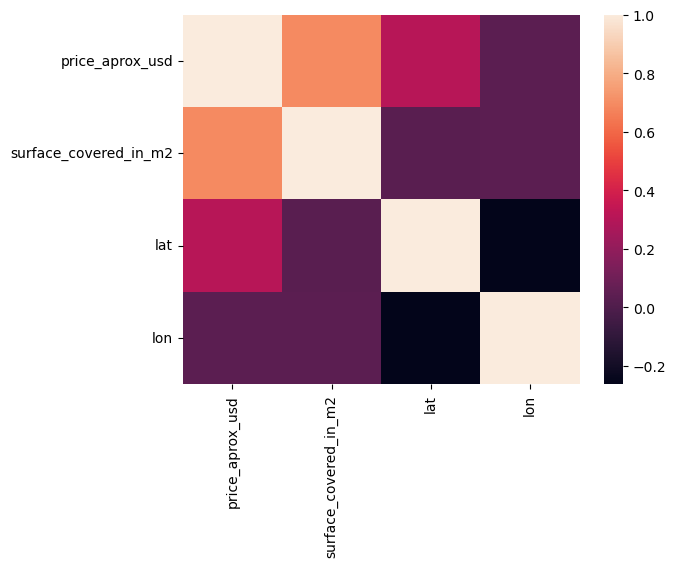

In [16]:
corr = df.select_dtypes("number").corr()
sns.heatmap(corr)

**Task 9:** Modify your `wrangle` function to remove columns so that there are no strongly correlated features in your feature matrix.

Be sure to rerun all the cells above before you continue.

### Split Data

**Task 10:** Create your feature matrix `X_train` and target vector `y_train`. Your target is `"price_aprox_usd"`. Your features should be all the columns that remain in the DataFrame you cleaned above.


In [17]:
target = "price_aprox_usd"
features = ["surface_covered_in_m2", "lat", "lon", "neighborhood"]
x = df[features]
y = df[target]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## Build Model

**Task 11:** Calculate the baseline mean absolute error for your model.

In [19]:
print("Mean apt price:", y_train.mean())
y_pred_baseline = [y_train.mean()]*len(y_train)
print("Baseline MAE:", mean_absolute_error(y_train, y_pred_baseline))

Mean apt price: 132850.52709591645
Baseline MAE: 45163.45921644359


### Iterate

**Task 12:** Create a pipeline named `model` that contains a `OneHotEncoder`, `SimpleImputer`, and `Ridge` predictor.

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6582 entries, 0 to 6581
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   price_aprox_usd        6582 non-null   float64
 1   surface_covered_in_m2  6582 non-null   float64
 2   lat                    6316 non-null   float64
 3   lon                    6316 non-null   float64
 4   neighborhood           6582 non-null   object 
dtypes: float64(4), object(1)
memory usage: 257.2+ KB


In [21]:
num_cols = X_train[["surface_covered_in_m2", "lat", "lon"]]
imputer = SimpleImputer()

In [22]:
imputer.fit_transform(num_cols)

array([[ 40.        , -34.555915  , -58.4634022 ],
       [ 71.        , -34.54179   , -58.476815  ],
       [ 38.        , -34.5756792 , -58.43053888],
       ...,
       [ 30.        , -34.5990818 , -58.3791226 ],
       [ 45.        , -34.5554838 , -58.4626315 ],
       [ 69.        , -34.5804119 , -58.4295334 ]])

In [24]:
pd.DataFrame(num_cols, columns=num_cols.columns).info()

<class 'pandas.core.frame.DataFrame'>
Index: 5265 entries, 3220 to 860
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   surface_covered_in_m2  5265 non-null   float64
 1   lat                    5056 non-null   float64
 2   lon                    5056 non-null   float64
dtypes: float64(3)
memory usage: 164.5 KB


In [25]:
cat_cols = X_train["neighborhood"]
ohe = OneHotEncoder()
ohe.fit(cat_cols)

OneHotEncoder(cols=['neighborhood'])

In [26]:
cat_cols_train = ohe.transform(cat_cols)
print(cat_cols_train.shape)
cat_cols_train.head(
    
)

(5265, 57)


,neighborhood_1,neighborhood_2,neighborhood_3,neighborhood_4,neighborhood_5,neighborhood_6,neighborhood_7,neighborhood_8,neighborhood_9,neighborhood_10,...,neighborhood_48,neighborhood_49,neighborhood_50,neighborhood_51,neighborhood_52,neighborhood_53,neighborhood_54,neighborhood_55,neighborhood_56,neighborhood_57
3220,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1859,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4307,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6240,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3182,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [27]:
model = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    SimpleImputer(),
    Ridge()
)

model.fit(X_train, y_train)

Pipeline(steps=[('onehotencoder',
                 OneHotEncoder(cols=['neighborhood'], use_cat_names=True)),
                ('simpleimputer', SimpleImputer()), ('ridge', Ridge())])

### Evaluate

**Task 13:** Calculate the training mean absolute error for your predictions as compared to the true targets in `y_train`.

In [28]:
y_pred_training = model.predict(X_train)
print("Training MAE:", mean_absolute_error(y_train, y_pred_training))

Training MAE: 24459.447938553632


## Communicate Results

In [29]:
y_pred_testing = model.predict(X_test)
print("Training MAE:", mean_absolute_error(y_test, y_pred_testing))

Training MAE: 23630.33139154115
